# TP1_WTS - Exploratory Data Analysis Project

## Dataset
This project analyzes the **Midwest** dataset, a county-level demographic dataset derived from the **2000 U.S. Census**. It contains 437 counties from five Midwestern states and includes population totals, racial composition, education levels, poverty rates, metro status, and county category labels.

## Why this dataset?
This dataset fits the project requirements well because it has:
- **28 variables**, which exceeds the 20-variable minimum
- a useful mix of **categorical** and **continuous** variables
- enough observations to support distributions, scatterplots, pairwise plots, correlations, and categorical comparisons
- strong real-world relevance for demographic and socioeconomic exploration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
sns.set_style("whitegrid")


In [2]:
data = pd.read_csv('dataset.csv')
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")
data.head()

Rows: 437, Columns: 28


,PID,county,state,area,poptotal,popdensity,popwhite,popblack,popamerindian,popasian,popother,percwhite,percblack,percamerindan,percasian,percother,popadults,perchsd,percollege,percprof,poppovertyknown,percpovertyknown,percbelowpoverty,percchildbelowpovert,percadultpoverty,percelderlypoverty,inmetro,category
0,561,ADAMS,IL,0.052,66090,1270.961540,63917,1702,98,249,124,96.712059,2.575276,0.148283,0.376759,0.187623,43298,75.107395,19.631392,4.355859,63628,96.274777,13.151443,18.011717,11.009776,12.443812,0,AAR
1,562,ALEXANDER,IL,0.014,10626,759.000000,7054,3496,19,48,9,66.384340,32.900433,0.178807,0.451722,0.084698,6724,59.726353,11.243308,2.870315,10529,99.087145,32.244278,45.826514,27.385647,25.228976,0,LHR
2,563,BOND,IL,0.022,14991,681.409091,14477,429,35,16,34,96.571276,2.861717,0.233473,0.106731,0.226803,9669,69.334988,17.033819,4.488572,14235,94.956974,12.068844,14.036061,10.852090,12.697410,0,AAR
3,564,BOONE,IL,0.017,30806,1812.117650,29344,127,46,150,1139,95.254171,0.412257,0.149322,0.486918,3.697332,19272,75.472188,17.278954,4.197800,30337,98.477569,7.209019,11.179536,5.536013,6.217047,1,ALU
4,565,BROWN,IL,0.018,5836,324.222222,5264,547,14,5,6,90.198766,9.372858,0.239890,0.085675,0.102810,3979,68.861523,14.475999,3.367680,4815,82.505140,13.520249,13.022889,11.143211,19.200000,0,AAR


## Data Cleaning

The dataset was checked for missing values, invalid entries, and inconsistent data types.
- No missing values were found.
- Numeric variables were already stored with numeric pandas dtypes.
- `PID` behaves like an identifier rather than an analytical feature.
- `county` is technically categorical, but because each county is almost unique, it is treated as an identifier-like field instead of a meaningful grouping variable for frequency tables.


In [3]:
# Missing values
missing_summary = data.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

Series([], dtype: int64)

In [4]:
# Table 1 - variable names, measurement level, pandas dtype, and percent missing
nominal = {'PID','county','state','inmetro','category'}
table1 = pd.DataFrame({
    'Variable Name': data.columns,
    'Data Type': ['Nominal' if c in nominal else 'Ratio' for c in data.columns],
    'Pandas dtype': [str(data[c].dtype) for c in data.columns],
    'Percent Missing': [(data[c].isna().mean()*100).round(2) for c in data.columns]
})
table1

,Variable Name,Data Type,Pandas dtype,Percent Missing
0,PID,Nominal,int64,0.0
1,county,Nominal,object,0.0
2,state,Nominal,object,0.0
3,area,Ratio,float64,0.0
4,poptotal,Ratio,int64,0.0
5,popdensity,Ratio,float64,0.0
6,popwhite,Ratio,int64,0.0
7,popblack,Ratio,int64,0.0
8,popamerindian,Ratio,int64,0.0
9,popasian,Ratio,int64,0.0


In [5]:
# Table 2 - summary statistics for numeric variables
table2 = data.describe().T.reset_index().rename(columns={
    'index':'Variable',
    'count':'Count',
    'mean':'Mean',
    'std':'Std Dev',
    'min':'Min',
    '25%':'25%',
    '50%':'50%',
    '75%':'75%',
    'max':'Max'
})
table2 = table2[['Variable','Count','Mean','Std Dev','Min','25%','50%','75%','Max']].round(3)
table2

,Variable,Count,Mean,Std Dev,Min,25%,50%,75%,Max
0,PID,437.0,1437.339,876.390,561.000,670.000,1221.000,2059.000,3052.000
1,area,437.0,0.033,0.015,0.005,0.024,0.030,0.038,0.110
2,poptotal,437.0,96130.302,298170.540,1701.000,18840.000,35324.000,75651.000,5105067.000
3,popdensity,437.0,3097.743,7664.752,85.050,622.407,1156.208,2330.000,88018.397
4,popwhite,437.0,81839.915,200196.648,416.000,18630.000,34471.000,72968.000,3204947.000
5,popblack,437.0,11023.881,78958.267,0.000,29.000,201.000,1291.000,1317147.000
6,popamerindian,437.0,343.110,868.927,4.000,44.000,94.000,288.000,10289.000
7,popasian,437.0,1310.465,9518.394,0.000,35.000,102.000,401.000,188565.000
8,popother,437.0,1612.931,18526.541,0.000,20.000,66.000,345.000,384119.000
9,percwhite,437.0,95.558,7.087,10.694,94.886,98.033,99.075,99.823


In [6]:
# Frequency tables for categorical variables used in the analysis
categorical_vars = ['state', 'inmetro', 'category']
cat_tables = {}
for col in categorical_vars:
    tbl = data[col].value_counts(dropna=False).rename_axis(col).reset_index(name='Frequency')
    tbl['Proportion'] = (tbl['Frequency'] / len(data)).round(4)
    cat_tables[col] = tbl
    print(f"\nFrequency table for {col}")
    display(tbl)



Frequency table for state


,state,Frequency,Proportion
0,IL,102,0.2334
1,IN,92,0.2105
2,OH,88,0.2014
3,MI,83,0.1899
4,WI,72,0.1648



Frequency table for inmetro


,inmetro,Frequency,Proportion
0,0,287,0.6568
1,1,150,0.3432



Frequency table for category


,category,Frequency,Proportion
0,AAR,193,0.4416
1,AAU,77,0.1762
2,LAR,30,0.0686
3,LHR,28,0.0641
4,HLU,26,0.0595
5,ALU,20,0.0458
6,HAU,20,0.0458
7,AHR,16,0.0366
8,ALR,11,0.0252
9,HAR,6,0.0137


In [7]:
# Correlation matrix for continuous variables
numeric_data = data.select_dtypes(include='number')
corr = numeric_data.corr(numeric_only=True)
corr.round(3)

,PID,area,poptotal,popdensity,popwhite,popblack,popamerindian,popasian,popother,percwhite,percblack,percamerindan,percasian,percother,popadults,perchsd,percollege,percprof,poppovertyknown,percpovertyknown,percbelowpoverty,percchildbelowpovert,percadultpoverty,percelderlypoverty,inmetro
PID,1.000,0.309,-0.009,0.020,0.005,-0.030,0.109,-0.041,-0.050,-0.009,-0.102,0.141,0.020,-0.074,-0.009,0.096,0.071,-0.108,-0.009,0.069,0.014,0.037,0.018,-0.104,0.006
area,0.309,1.000,0.067,-0.059,0.067,0.053,0.188,0.081,0.077,-0.047,-0.046,0.107,0.119,0.017,0.066,0.147,0.150,0.025,0.066,-0.114,0.073,0.052,0.102,-0.008,-0.106
poptotal,-0.009,0.067,1.000,0.898,0.989,0.947,0.815,0.923,0.858,-0.475,0.553,-0.031,0.451,0.462,1.000,0.137,0.301,0.276,1.000,0.035,-0.029,0.026,-0.031,-0.149,0.308
popdensity,0.020,-0.059,0.898,1.000,0.918,0.823,0.797,0.726,0.614,-0.521,0.631,-0.041,0.467,0.409,0.897,0.172,0.350,0.319,0.897,0.050,-0.052,0.021,-0.056,-0.202,0.388
popwhite,0.005,0.067,0.989,0.918,1.000,0.894,0.811,0.895,0.806,-0.481,0.562,-0.040,0.502,0.464,0.989,0.191,0.365,0.330,0.989,0.034,-0.065,-0.008,-0.061,-0.202,0.367
popblack,-0.030,0.053,0.947,0.823,0.894,1.000,0.785,0.864,0.838,-0.461,0.548,-0.016,0.303,0.398,0.946,0.018,0.152,0.151,0.948,0.041,0.055,0.107,0.038,-0.031,0.185
popamerindian,0.109,0.188,0.815,0.797,0.811,0.785,1.000,0.684,0.614,-0.613,0.517,0.253,0.382,0.361,0.812,0.141,0.283,0.225,0.815,-0.003,0.097,0.150,0.092,-0.116,0.265
popasian,-0.041,0.081,0.923,0.726,0.895,0.864,0.684,1.000,0.963,-0.332,0.345,-0.016,0.444,0.447,0.925,0.091,0.237,0.232,0.923,0.011,-0.013,0.013,-0.010,-0.083,0.173
popother,-0.050,0.077,0.858,0.614,0.806,0.838,0.614,0.963,1.000,-0.284,0.287,-0.010,0.293,0.482,0.860,0.020,0.117,0.114,0.858,0.026,0.007,0.038,-0.001,-0.036,0.111
percwhite,-0.009,-0.047,-0.475,-0.521,-0.481,-0.461,-0.613,-0.332,-0.284,1.000,-0.760,-0.595,-0.319,-0.342,-0.471,-0.019,-0.215,-0.221,-0.474,0.125,-0.377,-0.413,-0.350,-0.043,-0.264


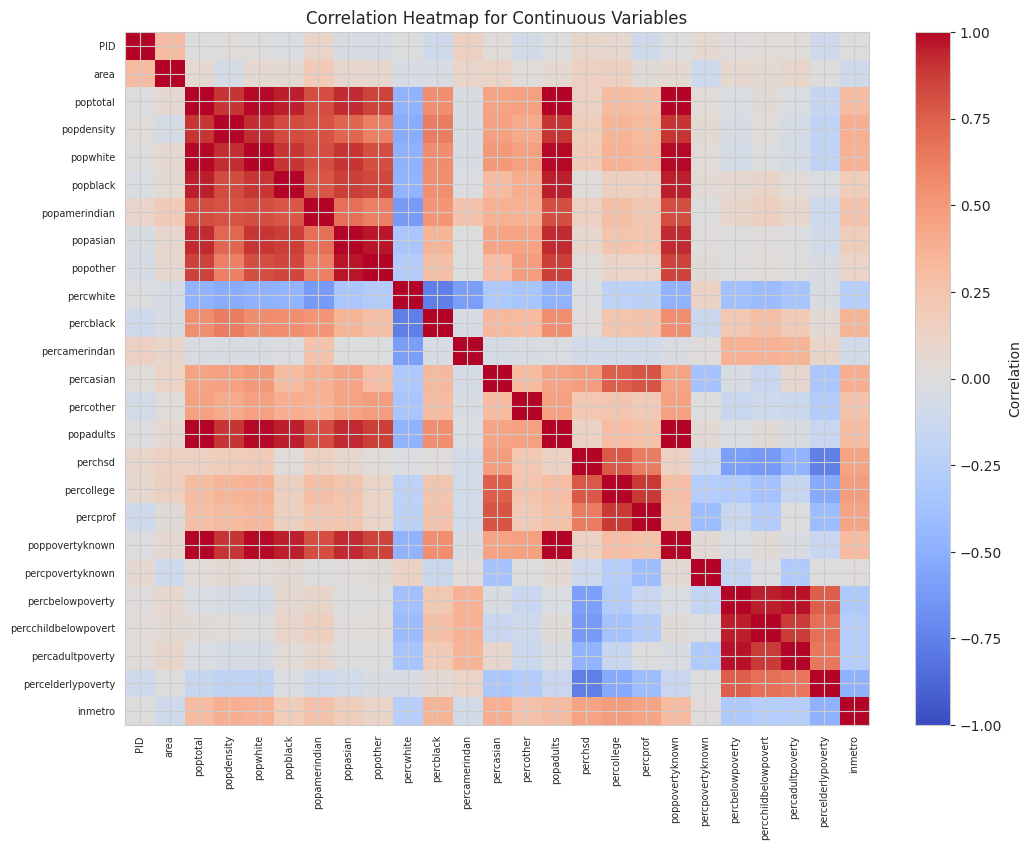

In [8]:
plt.figure(figsize=(12,9))
plt.imshow(corr, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr.index)), corr.index, fontsize=7)
plt.title('Correlation Heatmap for Continuous Variables')
plt.show()

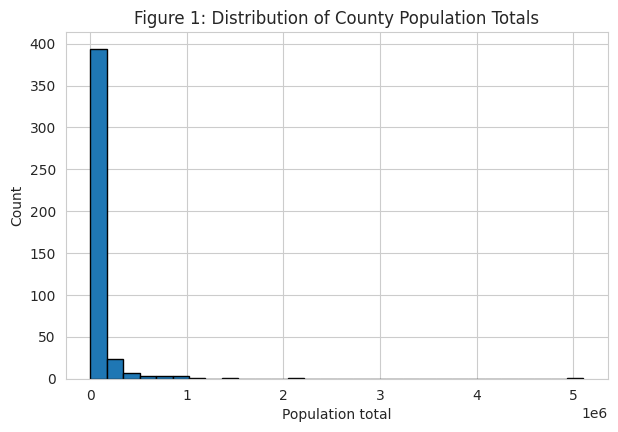

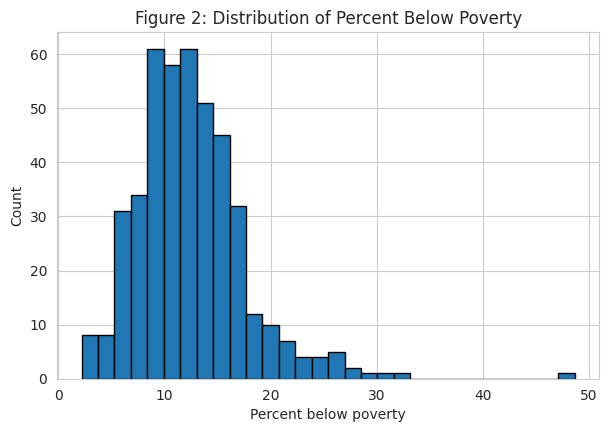

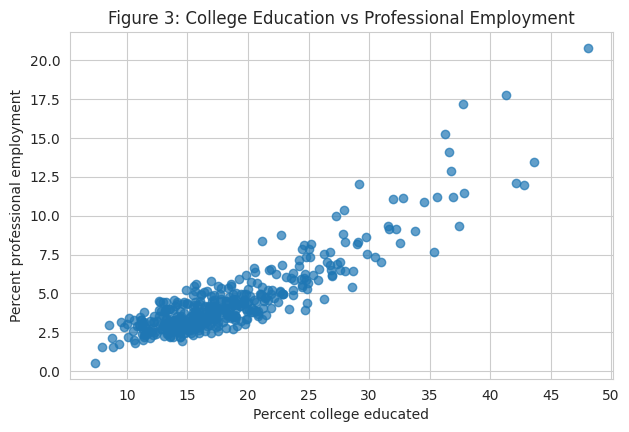

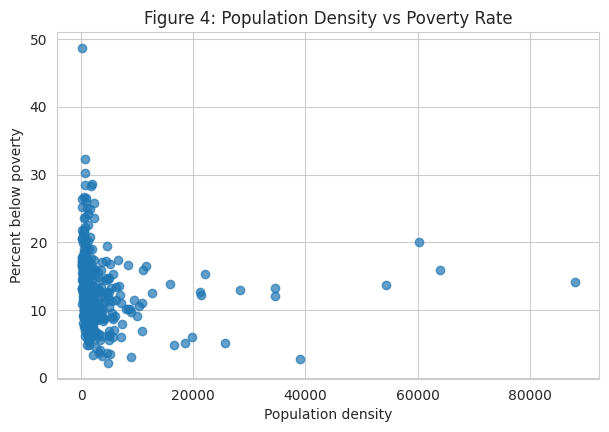

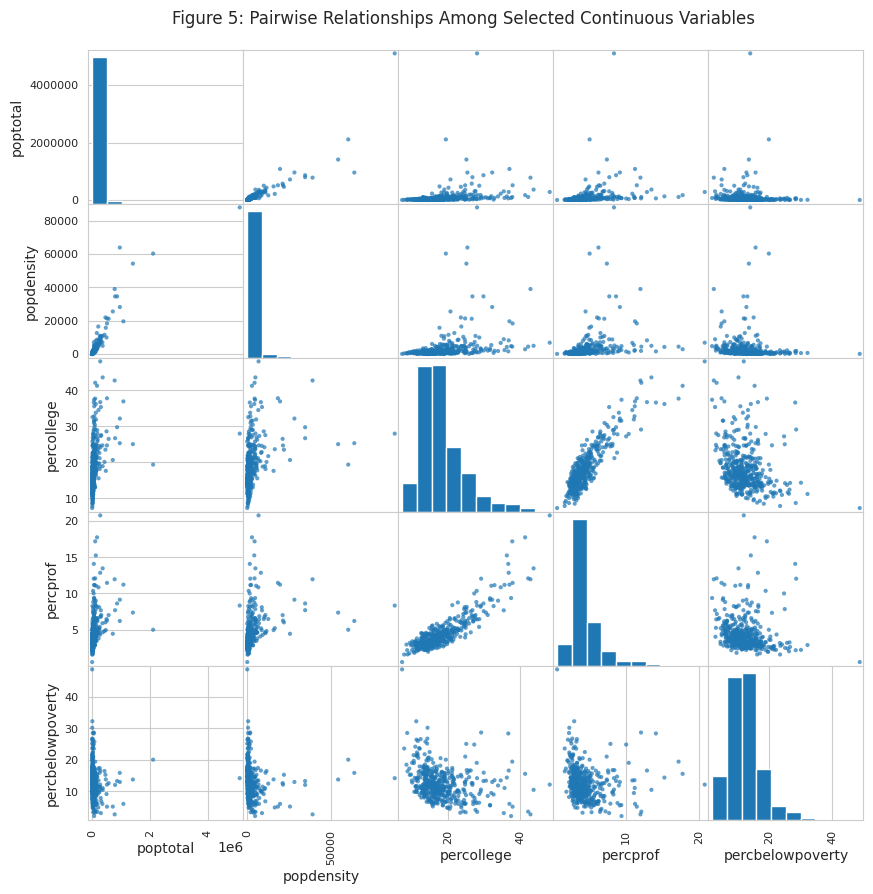

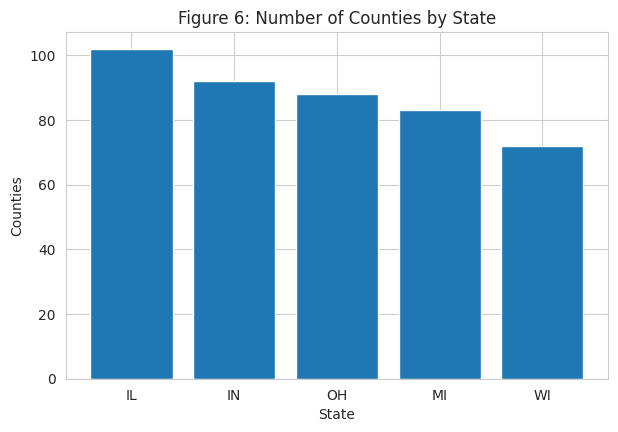

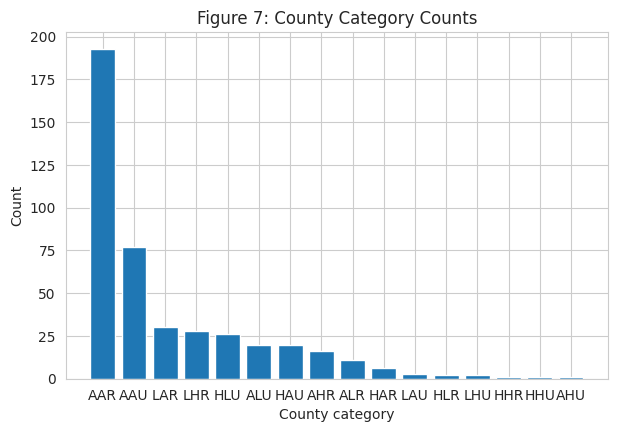

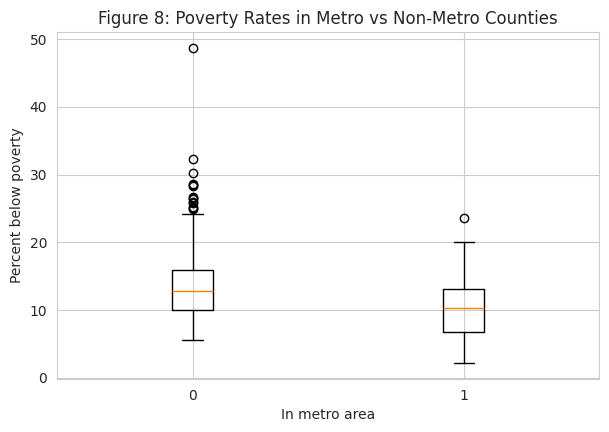

In [9]:
# Histogram 1
plt.figure(figsize=(7,4.5))
plt.hist(data['poptotal'], bins=30, edgecolor='black')
plt.title('Figure 1: Distribution of County Population Totals')
plt.xlabel('Population total')
plt.ylabel('Count')
plt.show()

# Histogram 2
plt.figure(figsize=(7,4.5))
plt.hist(data['percbelowpoverty'], bins=30, edgecolor='black')
plt.title('Figure 2: Distribution of Percent Below Poverty')
plt.xlabel('Percent below poverty')
plt.ylabel('Count')
plt.show()

# Scatterplot 1
plt.figure(figsize=(7,4.5))
plt.scatter(data['percollege'], data['percprof'], alpha=0.7)
plt.title('Figure 3: College Education vs Professional Employment')
plt.xlabel('Percent college educated')
plt.ylabel('Percent professional employment')
plt.show()

# Scatterplot 2
plt.figure(figsize=(7,4.5))
plt.scatter(data['popdensity'], data['percbelowpoverty'], alpha=0.7)
plt.title('Figure 4: Population Density vs Poverty Rate')
plt.xlabel('Population density')
plt.ylabel('Percent below poverty')
plt.show()

# Pairwise plot
scatter_matrix(data[['poptotal','popdensity','percollege','percprof','percbelowpoverty']], figsize=(10,10), diagonal='hist', alpha=0.7)
plt.suptitle('Figure 5: Pairwise Relationships Among Selected Continuous Variables', y=0.92)
plt.show()

# Bar chart 1
state_counts = data['state'].value_counts()
plt.figure(figsize=(7,4.5))
plt.bar(state_counts.index, state_counts.values)
plt.title('Figure 6: Number of Counties by State')
plt.xlabel('State')
plt.ylabel('Counties')
plt.show()

# Bar chart 2
cat_counts = data['category'].value_counts()
plt.figure(figsize=(7,4.5))
plt.bar(cat_counts.index.astype(str), cat_counts.values)
plt.title('Figure 7: County Category Counts')
plt.xlabel('County category')
plt.ylabel('Count')
plt.show()

# Boxplot
groups = [data.loc[data['inmetro']==i,'percbelowpoverty'] for i in sorted(data['inmetro'].unique())]
plt.figure(figsize=(7,4.5))
plt.boxplot(groups, tick_labels=[str(i) for i in sorted(data['inmetro'].unique())])
plt.title('Figure 8: Poverty Rates in Metro vs Non-Metro Counties')
plt.xlabel('In metro area')
plt.ylabel('Percent below poverty')
plt.show()


In [10]:
# Simple findings used in the written discussion
print('Average poverty rate by metro status:')
print(data.groupby('inmetro')['percbelowpoverty'].mean().round(2))
print('\nTop county category counts:')
print(data['category'].value_counts())
print('\nStrongest negative correlation:')
corr_pairs = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack().sort_values()
print(corr_pairs.head(1))


Average poverty rate by metro status:
inmetro
0    13.67
1    10.29
Name: percbelowpoverty, dtype: float64

Top county category counts:
category
AAR    193
AAU     77
LAR     30
LHR     28
HLU     26
ALU     20
HAU     20
AHR     16
ALR     11
HAR      6
LAU      3
HLR      2
LHU      2
HHR      1
HHU      1
AHU      1
Name: count, dtype: int64

Strongest negative correlation:
percwhite  percblack   -0.759585
dtype: float64


## Summary of Findings

This dataset shows clear demographic and socioeconomic differences across Midwestern counties. Population, education, and poverty measures create several visible patterns. In particular, metro counties tend to have lower poverty rates on average than non-metro counties, and counties with higher college attainment also tend to have higher professional employment shares. The correlation analysis also shows that some percentage-based racial composition variables move in opposite directions, which is expected because the categories together make up the same total population base.

Overall, the dataset is well suited for exploratory data analysis because it supports numerical summaries, categorical comparisons, and multiple visual methods without requiring major data repair.
